# Día 2 — Construcción del Agente Multi-Paso (5h)

**Grupo 5 — Agente multi-paso (MedSAM + CNN + Gemini)**
**Proyecto**: Clasificación de posicionamiento de dedo en escáner biométrico
**Fecha**: Mayo 2026

---

## Objetivo del día

Implementar e integrar la clase `AgenteMedico` que orquesta el pipeline completo:

| Tarea | Tiempo |
|-------|--------|
| Tarea 1: Implementar clase `AgenteMedico` con sus 5 métodos | 2.5h |
| Tarea 2: Integrar MedSAM + ResidualCNN + Gemini en el agente | 1.5h |
| Tarea 3: Prueba end-to-end — 5 imágenes alta confianza + 5 baja confianza | 1h |

> **Decisiones del Día 1 aplicadas aquí:**
> - Umbral MedSAM: `score >= 0.60` para pasar al siguiente paso
> - Umbral CNN: `p_cnn >= 0.70` para veredicto directo; `< 0.70` activa Gemini
> - Modelo CNN: `ResidualCNN` (mejor arquitectura del Grupo 2, `best_ResidualCNN.pth`)
> - API Gemini: `google/gemini-2.0-flash-lite-001` vía OpenRouter

## Tarea 1 + 2 — Implementación e integración

### 0. Imports

In [1]:
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import numpy as np
from PIL import Image
from io import BytesIO
import base64
import os
import json
import random
from pathlib import Path
from dotenv import find_dotenv, load_dotenv
from openai import OpenAI
from segment_anything import sam_model_registry, SamPredictor
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

print(f"PyTorch : {torch.__version__}")
print(f"CUDA    : {torch.cuda.is_available()}")

PyTorch : 2.11.0+cu130
CUDA    : False


### 1. Configuración global

In [2]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Encontrar la raíz del proyecto buscando .git hacia arriba (funciona
# independientemente de desde dónde se lance Jupyter)
def _find_project_root():
    current = Path(os.getcwd()).resolve()
    for p in [current] + list(current.parents):
        if (p / ".git").exists():
            return p
    return current

PROJECT_ROOT = _find_project_root()
MEDSAM_CKPT  = PROJECT_ROOT / "MedSAM_GeminiAPI/Dia1/medsam_vit_b.pth"
CNN_CKPT     = PROJECT_ROOT / "CNN_desde_0/modelosEntrenados/best_ResidualCNN.pth"
DATASET_DIR  = PROJECT_ROOT / "CNN_desde_0/imagenes_procesadas"
GEMINI_MODEL = "google/gemini-2.0-flash-lite-001"

UMBRAL_CNN    = 0.70   # Día 1: p_cnn < 0.70 → Gemini arbitra
UMBRAL_MEDSAM = 0.60   # Día 1: score < 0.60 → error, imagen no válida

IDX_TO_LABEL = {0: "no", 1: "si"}   # igual que en CNN_Main_Final.ipynb

CNN_TRANSFORM = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

print(f"Raíz del proyecto: {PROJECT_ROOT}")
print("\nVerificando rutas...")
for nombre, ruta in [("MedSAM checkpoint", MEDSAM_CKPT),
                     ("ResidualCNN pesos",  CNN_CKPT),
                     ("Dataset",            DATASET_DIR)]:
    ok = "✓" if ruta.exists() else "✗  FALTA"
    print(f"  {ok}  {nombre}: {ruta}")

print(f"\nDevice        : {DEVICE}")
print(f"Umbral CNN    : {UMBRAL_CNN}")
print(f"Umbral MedSAM : {UMBRAL_MEDSAM}")

Raíz del proyecto: /home/carlos/Escritorio/Carlos/Prog/Programacio/ProyectoFinal_CSEBDIA

Verificando rutas...
  ✓  MedSAM checkpoint: /home/carlos/Escritorio/Carlos/Prog/Programacio/ProyectoFinal_CSEBDIA/MedSAM_GeminiAPI/Dia1/medsam_vit_b.pth
  ✓  ResidualCNN pesos: /home/carlos/Escritorio/Carlos/Prog/Programacio/ProyectoFinal_CSEBDIA/CNN_desde_0/modelosEntrenados/best_ResidualCNN.pth
  ✓  Dataset: /home/carlos/Escritorio/Carlos/Prog/Programacio/ProyectoFinal_CSEBDIA/CNN_desde_0/imagenes_procesadas

Device        : cpu
Umbral CNN    : 0.7
Umbral MedSAM : 0.6


### 2. Cargar MedSAM

Se reutiliza la carga robusta del Día 2 de MedSAM (soporta checkpoints con y sin clave `model`).

In [3]:
raw = torch.load(MEDSAM_CKPT, map_location=DEVICE)
sam = sam_model_registry["vit_b"](checkpoint=None)
state = raw.get("model", raw) if isinstance(raw, dict) else raw
if isinstance(state, dict):
    missing, unexpected = sam.load_state_dict(state, strict=False)
    if missing:
        print(f"  Claves faltantes: {len(missing)}")

sam.to(DEVICE).eval()
predictor = SamPredictor(sam)
n_params = sum(p.numel() for p in sam.parameters())
print(f"✓ MedSAM (ViT-B) cargado — {n_params/1e6:.1f}M parámetros — device: {DEVICE}")

✓ MedSAM (ViT-B) cargado — 93.7M parámetros — device: cpu


### 3. Cargar ResidualCNN

Se define la arquitectura exactamente igual que en `CNN_Main_Final.ipynb` (Grupo 2)
para poder cargar los pesos de `best_ResidualCNN.pth`.

In [4]:
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1, downsample=None):
        super().__init__()
        self.conv1      = nn.Conv2d(in_channels, out_channels, 3, stride=stride, padding=1, bias=False)
        self.bn1        = nn.BatchNorm2d(out_channels)
        self.relu       = nn.ReLU(inplace=True)
        self.conv2      = nn.Conv2d(out_channels, out_channels, 3, padding=1, bias=False)
        self.bn2        = nn.BatchNorm2d(out_channels)
        self.downsample = downsample

    def forward(self, x):
        identity = x
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        if self.downsample is not None:
            identity = self.downsample(x)
        return self.relu(out + identity)


class ResidualCNN(nn.Module):
    def __init__(self, in_channels=3, num_classes=2):
        super().__init__()
        self.conv1  = nn.Sequential(
            nn.Conv2d(in_channels, 32, 7, stride=2, padding=3, bias=False),
            nn.BatchNorm2d(32), nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        )
        self.layer1 = self._make_layer(32,  64,  2)
        self.layer2 = self._make_layer(64,  128, 2, stride=2)
        self.layer3 = self._make_layer(128, 256, 2, stride=2)
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 128), nn.BatchNorm1d(128), nn.ReLU(inplace=True), nn.Dropout(0.4),
            nn.Linear(128, num_classes)
        )

    def _make_layer(self, in_ch, out_ch, blocks, stride=1):
        down = None
        if stride != 1 or in_ch != out_ch:
            down = nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 1, stride=stride, bias=False),
                nn.BatchNorm2d(out_ch)
            )
        layers = [ResidualBlock(in_ch, out_ch, stride, down)]
        for _ in range(1, blocks):
            layers.append(ResidualBlock(out_ch, out_ch))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.conv1(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.avgpool(x)
        return self.fc(x)


model_cnn = ResidualCNN(in_channels=3, num_classes=2).to(DEVICE)
model_cnn.load_state_dict(torch.load(CNN_CKPT, map_location=DEVICE))
model_cnn.eval()
n = sum(p.numel() for p in model_cnn.parameters())
print(f"✓ ResidualCNN cargada — {n:,} parámetros — device: {DEVICE}")

✓ ResidualCNN cargada — 2,795,170 parámetros — device: cpu


### 4. Configurar cliente Gemini (OpenRouter)

La API key se carga del `.env` del proyecto (`OPENROUTER_API_KEY`).

In [5]:
load_dotenv(find_dotenv())
OPENROUTER_API_KEY = os.environ.get("OPENROUTER_API_KEY")
if not OPENROUTER_API_KEY:
    raise ValueError("No se encontró OPENROUTER_API_KEY en el .env")

client = OpenAI(
    base_url="https://openrouter.ai/api/v1",
    api_key=OPENROUTER_API_KEY,
)

# Verificación rápida
resp = client.chat.completions.create(
    model=GEMINI_MODEL,
    messages=[{"role": "user", "content": "Responde solo 'OK'."}]
)
print(f"✓ Gemini conectado: {resp.choices[0].message.content.strip()}")

✓ Gemini conectado: OK


### 5. Clase `AgenteMedico`

La clase implementa los 5 métodos definidos en el plan:

| Método | Paso | Descripción |
|--------|------|-------------|
| `segmentar()` | Paso 1 | MedSAM genera máscara + score |
| `clasificar()` | Paso 2 | ResidualCNN predice SI/NO + p_cnn |
| `necesita_arbitraje()` | Control | Comprueba si p_cnn < 0.70 |
| `consultar_gemini()` | Paso 3 | Gemini arbitra con imagen + máscara + contexto CNN |
| `veredicto_final()` | Orquestador | Pipeline completo, devuelve dict con todo el trazado |

In [6]:
class AgenteMedico:
    """
    Agente multi-paso MedSAM → ResidualCNN → Gemini.
    Diseño del Día 1, implementación del Día 2 — Grupo 5, Proyecto IA RX.
    """
    UMBRAL_CNN    = UMBRAL_CNN
    UMBRAL_MEDSAM = UMBRAL_MEDSAM

    def __init__(self, predictor, cnn, gemini_client, device="cpu"):
        self.predictor = predictor
        self.cnn       = cnn
        self.client    = gemini_client
        self.device    = device

    # ── Paso 1: MedSAM ────────────────────────────────────────────────────────
    def segmentar(self, img_array):
        """
        Segmenta el dedo con MedSAM usando bounding box central (margen 10%).
        Condición de paso: score >= UMBRAL_MEDSAM (0.60).
        Devuelve (mask_bool_array, score_float).
        """
        h, w = img_array.shape[:2]
        m    = 0.10
        bbox = np.array([[int(w*m), int(h*m), int(w*(1-m)), int(h*(1-m))]])
        self.predictor.set_image(img_array)
        masks, scores, _ = self.predictor.predict(box=bbox, multimask_output=True)
        idx   = int(np.argmax(scores))
        score = float(scores[idx])
        if score < self.UMBRAL_MEDSAM:
            raise ValueError(
                f"Segmentación insuficiente: score={score:.3f} < {self.UMBRAL_MEDSAM}"
            )
        return masks[idx], score

    # ── Paso 2: ResidualCNN ───────────────────────────────────────────────────
    def clasificar(self, img_array, mask):
        """
        Aplica la máscara MedSAM y clasifica con ResidualCNN.
        Condición de paso: p_cnn >= UMBRAL_CNN (0.70) → veredicto directo.
        Devuelve (clase_str, p_max) — clase_str es 'SI' o 'NO'.
        """
        img_masked = img_array.copy()
        img_masked[~mask] = 0                        # fuera de máscara → negro

        tensor = CNN_TRANSFORM(
            Image.fromarray(img_masked.astype(np.uint8))
        ).unsqueeze(0).to(self.device)

        with torch.no_grad():
            probs = torch.softmax(self.cnn(tensor), dim=1).squeeze().cpu().numpy()

        idx_pred = int(np.argmax(probs))
        clase    = IDX_TO_LABEL[idx_pred].upper()    # 'SI' o 'NO'
        return clase, float(probs[idx_pred])

    # ── Control: ¿necesita árbitro? ───────────────────────────────────────────
    def necesita_arbitraje(self, p_cnn):
        """
        True si la CNN es incierta (p_cnn < UMBRAL_CNN).
        False → veredicto directo de la CNN.
        """
        return p_cnn < self.UMBRAL_CNN

    # ── Paso 3: Gemini (condicional) ─────────────────────────────────────────
    def consultar_gemini(self, img_array, mask, pred_cnn, p_cnn):
        """
        Consulta a Gemini como árbitro multimodal.
        Recibe: imagen original + overlay MedSAM + predicción CNN + confianza.
        Devuelve: (clase_final_str, razon_str).
        """
        def _to_b64(arr):
            buf = BytesIO()
            pil = Image.fromarray(arr.astype(np.uint8))
            if pil.mode != "RGB":
                pil = pil.convert("RGB")
            pil.save(buf, format="JPEG", quality=85)
            return base64.b64encode(buf.getvalue()).decode()

        overlay         = img_array.copy()
        overlay[mask]   = [50, 220, 80]              # máscara en verde

        prompt = (
            "Eres un sistema experto en análisis de posicionamiento biométrico.\n"
            "Se te presentan dos imágenes de una radiografía térmica de un dedo sobre un escáner biométrico.\n\n"
            "IMAGEN 1: Fotografía original del dedo sobre el escáner.\n"
            "IMAGEN 2: Máscara de segmentación de MedSAM (región del dedo resaltada en verde).\n\n"
            f"El clasificador CNN predijo: [{pred_cnn}] con confianza [{p_cnn:.1%}].\n"
            "Esta confianza es BAJA (< 70%), necesitamos tu criterio.\n\n"
            "El escáner tiene una franja luminosa (zona brillante). El dedo entero debe quedar centrado\n"
            "encima de esa franja, sin desplazarse ni salirse. Ese es el único criterio.\n\n"
            "CORRECTO (SI):\n"
            "- El dedo está colocado encima de la franja luminosa y centrado en ella.\n"
            "- El dedo no se sale de la franja ni por los lados ni por arriba/abajo.\n"
            "- El dedo cubre la franja de forma plana, sin estar girado ni inclinado.\n\n"
            "INCORRECTO (NO):\n"
            "- El dedo está desplazado: parte del dedo queda fuera de la franja luminosa.\n"
            "- El dedo solo toca un extremo o un lado de la franja, no el centro.\n"
            "- El dedo está girado o inclinado de modo que no cubre bien la franja.\n\n"
            "Responde ÚNICAMENTE con este formato exacto:\n"
            "VEREDICTO: [SI / NO]\n"
            "RAZÓN: [Una sola frase con el criterio visual determinante]"
        )

        resp = self.client.chat.completions.create(
            model=GEMINI_MODEL,
            messages=[{"role": "user", "content": [
                {"type": "image_url",
                 "image_url": {"url": f"data:image/jpeg;base64,{_to_b64(img_array)}"}},
                {"type": "image_url",
                 "image_url": {"url": f"data:image/jpeg;base64,{_to_b64(overlay)}"}},
                {"type": "text", "text": prompt}
            ]}],
            temperature=0.1,
            max_tokens=200
        )

        raw = resp.choices[0].message.content.strip()
        clase_final, razon = "NO", raw

        for line in raw.splitlines():
            upper = line.upper()
            if upper.startswith("VEREDICTO:"):
                clase_final = "SI" if "SI" in upper else "NO"
            elif upper.startswith("RAZ"):
                razon = line.split(":", 1)[-1].strip()

        return clase_final, razon

    # ── Orquestador: pipeline completo ────────────────────────────────────────
    def veredicto_final(self, ruta_imagen):
        """
        Ejecuta el pipeline completo MedSAM → CNN → (Gemini si necesario).

        Devuelve dict con trazabilidad completa:
          imagen, error, score_medsam, clase_cnn, p_cnn,
          arbitraje_gemini, clase_final, razon_gemini
        """
        res = {
            "imagen"         : Path(ruta_imagen).name,
            "error"          : None,
            "score_medsam"   : None,
            "clase_cnn"      : None,
            "p_cnn"          : None,
            "arbitraje_gemini": False,
            "clase_final"    : None,
            "razon_gemini"   : None,
        }
        try:
            img = np.array(Image.open(ruta_imagen).convert("RGB"))

            # Paso 1
            mask, score = self.segmentar(img)
            res["score_medsam"] = round(score, 4)

            # Paso 2
            clase_cnn, p_cnn = self.clasificar(img, mask)
            res["clase_cnn"], res["p_cnn"] = clase_cnn, round(p_cnn, 4)

            # Paso 3 (condicional)
            if self.necesita_arbitraje(p_cnn):
                res["arbitraje_gemini"] = True
                clase_final, razon      = self.consultar_gemini(img, mask, clase_cnn, p_cnn)
                res["clase_final"]      = clase_final
                res["razon_gemini"]     = razon
            else:
                res["clase_final"] = clase_cnn

        except ValueError as e:
            res["error"] = str(e)

        return res

### 6. Instanciar el agente

In [7]:
agente = AgenteMedico(
    predictor     = predictor,
    cnn           = model_cnn,
    gemini_client = client,
    device        = str(DEVICE)
)
print("✓ AgenteMedico listo")
print(f"  Umbral CNN    : {agente.UMBRAL_CNN}")
print(f"  Umbral MedSAM : {agente.UMBRAL_MEDSAM}")

✓ AgenteMedico listo
  Umbral CNN    : 0.7
  Umbral MedSAM : 0.6


### Visualización: Pipeline completo de preprocesado — OpenCV (Oscar) + MedSAM

Para 6 imágenes (3 SI + 3 NO) se muestra el pipeline combinado en 6 pasos:

| Columna | Técnica | Qué hace |
|---------|---------|----------|
| ① | Original | Imagen cruda del escáner |
| ② | **Oscar** — Normalización + panel | Remapeo lineal de brillo, detección del panel negro (polígono rojo) |
| ③ | **Oscar** — Panel rectificado + mano | `warpPerspective` + segmentación de mano por YCrCb (verde) |
| ④ | **Oscar** — Ventana de luz | Detección de la zona luminosa dentro del panel |
| ⑤ | **MedSAM** — Segmentación | BBox del panel de Oscar como prompt → máscara precisa del dedo |
| ⑥ | Input CNN | Imagen original enmascarada con MedSAM → entrada al clasificador |

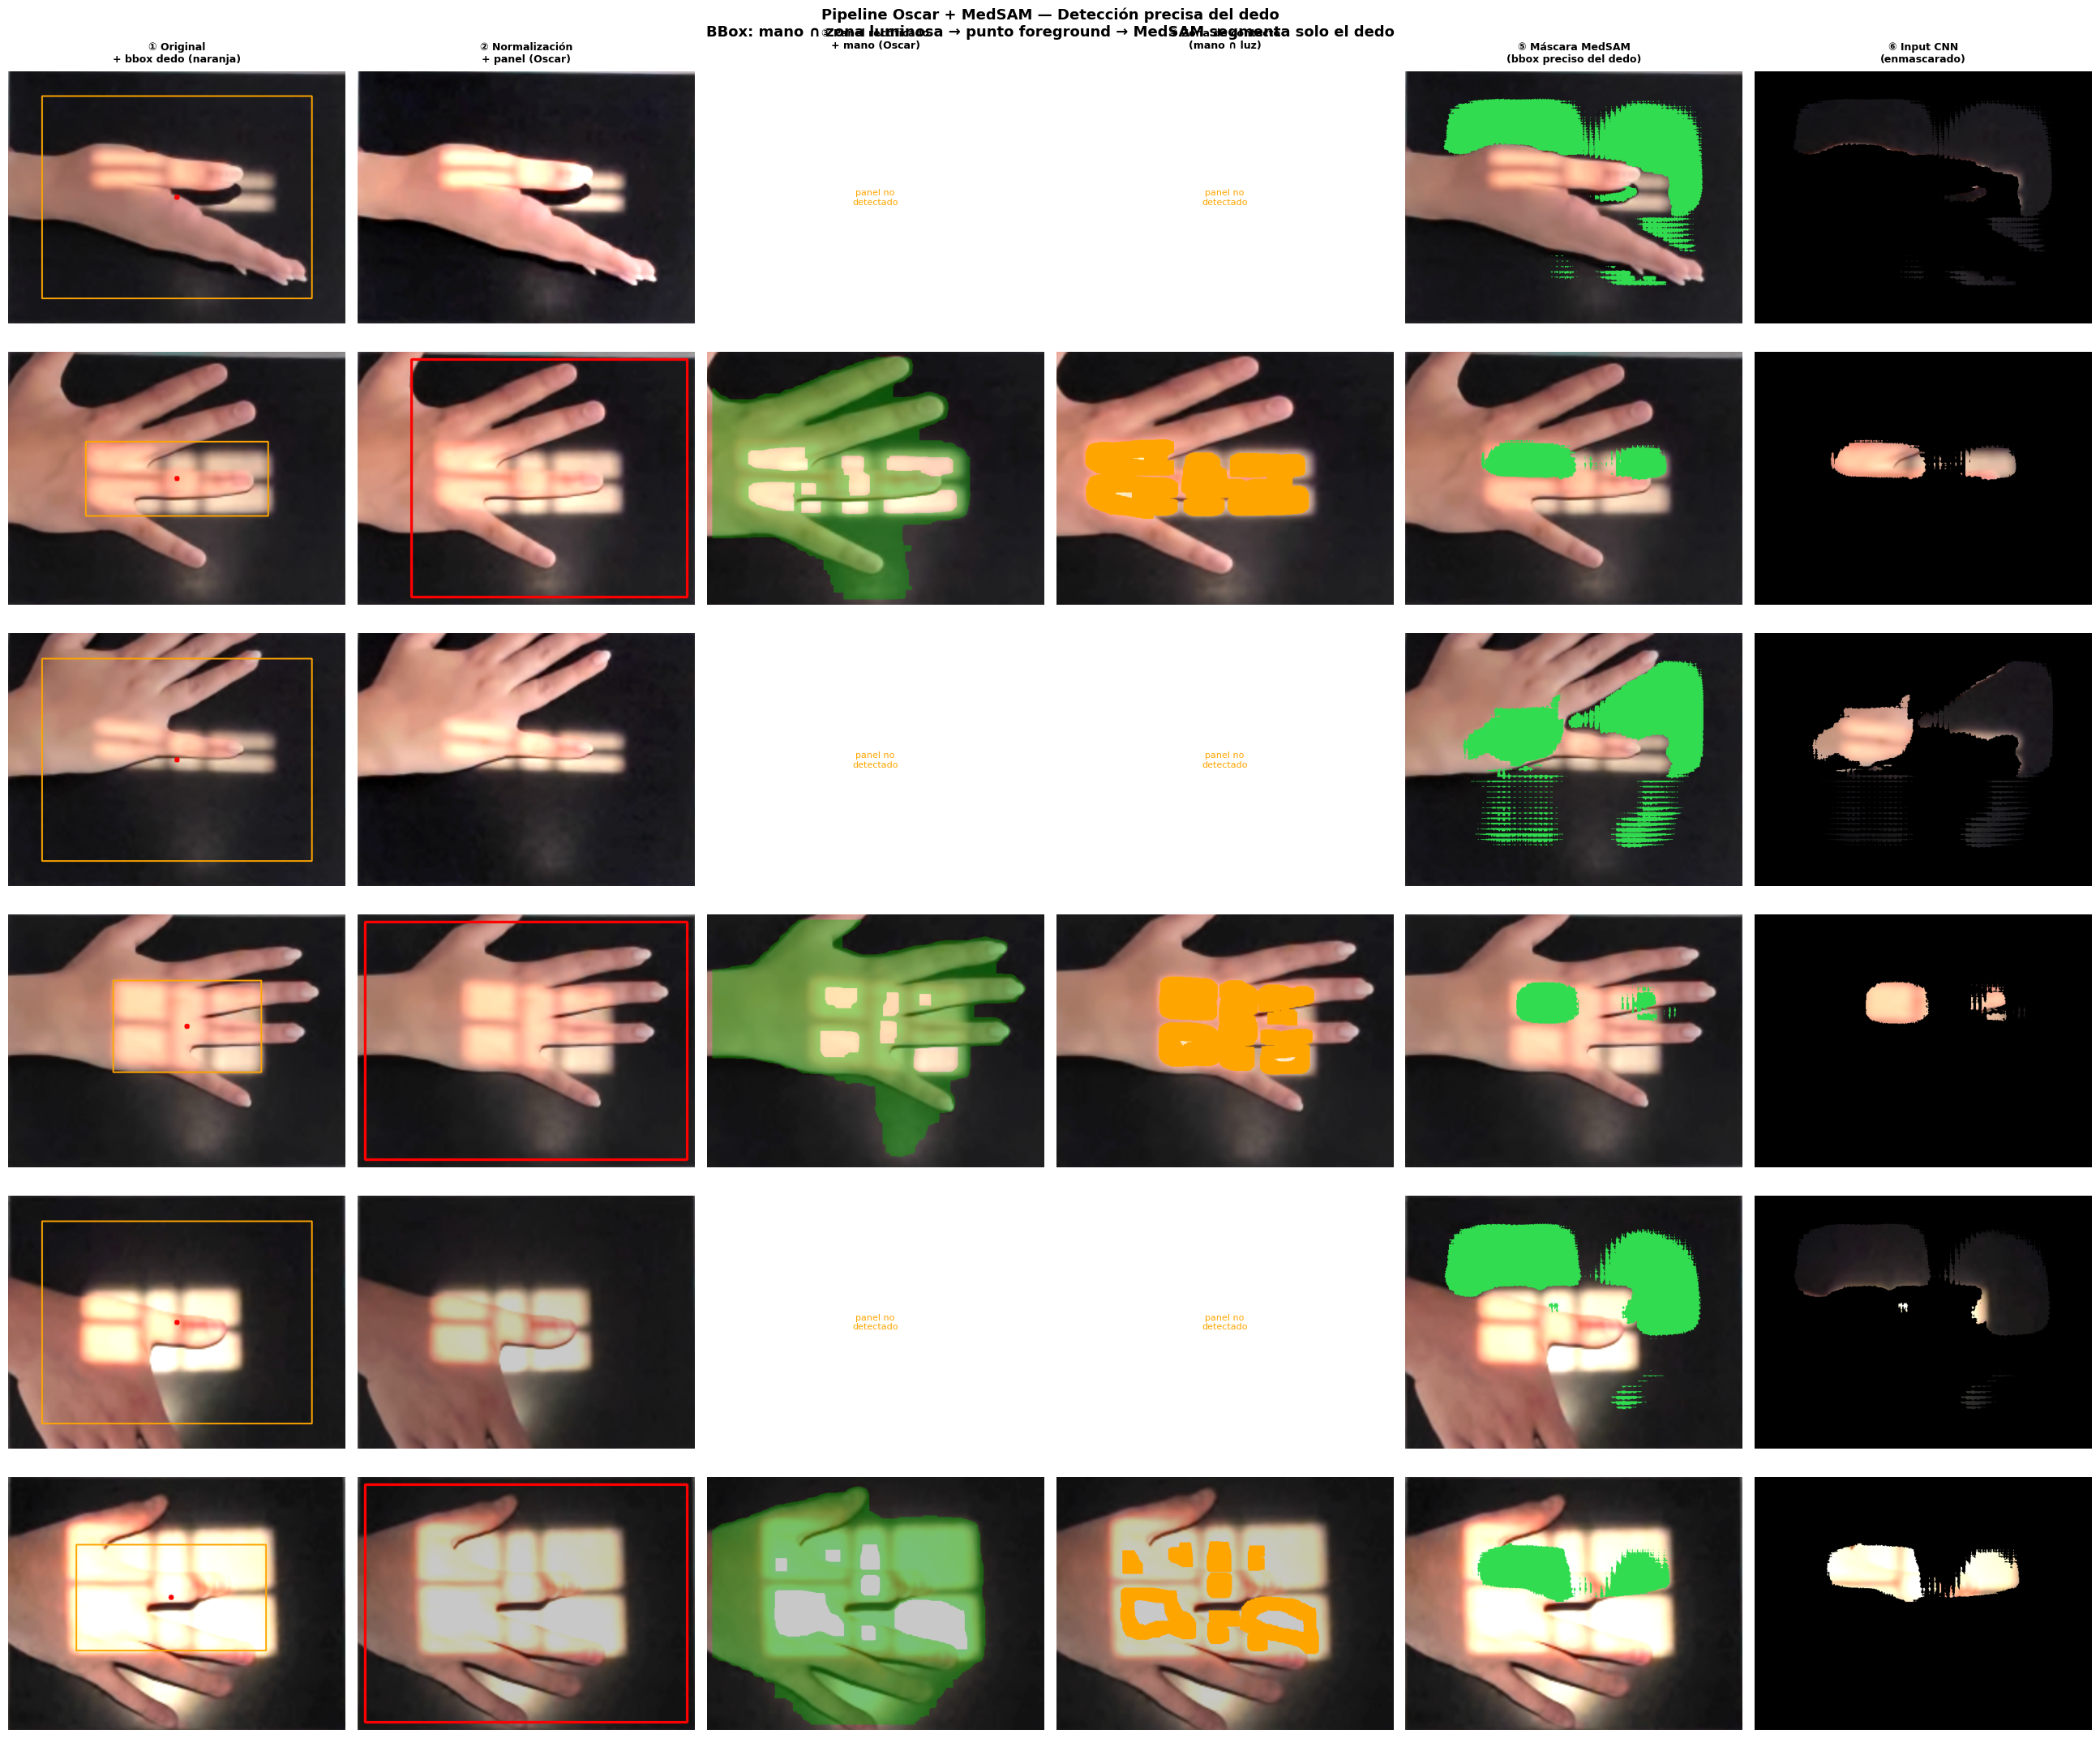

✓ oscar_medsam_pipeline_dia2.png guardada


In [8]:
import sys, cv2
from scipy.ndimage import binary_dilation
sys.path.insert(0, str(PROJECT_ROOT / "CNN_desde_0" / "CNNs_Oscar" / "dia4"))

from day1_opencv_helpers import (
    normalize_with_white_background,
    detect_black_panel,
    warp_panel,
    segment_hand,
    orient_panel_to_left,
    detect_light_window,
    draw_polygon,
    overlay_mask   as oscar_overlay,
    extract_box_region,
    fit_axis_aligned_box_to_mask,
)

random.seed(42)
PANEL_SIZE = (640, 480)
OSCAR_PARAMS = dict(
    target_background_gray     = 200,
    target_box_gray            = 25,
    dark_box_threshold         = 40,
    hand_background_threshold  = 80,
    hand_light_threshold       = 200,
    light_saturation_threshold = 120,
    panel_detection_threshold  = 60,
)

sample_si = random.sample(
    list((DATASET_DIR / "train" / "si").glob("*.png")) +
    list((DATASET_DIR / "test"  / "si").glob("*.png")), 3)
sample_no = random.sample(
    list((DATASET_DIR / "train" / "no").glob("*.png")) +
    list((DATASET_DIR / "test"  / "no").glob("*.png")), 3)
muestra   = sample_si + sample_no
etiquetas = ["SI"] * 3 + ["NO"] * 3

COL_TITLES = [
    "① Original\n+ bbox dedo (naranja)",
    "② Normalización\n+ panel (Oscar)",
    "③ Panel rectificado\n+ mano (Oscar)",
    "④ Zona de contacto\n(mano ∩ luz)",
    "⑤ Máscara MedSAM\n(bbox preciso del dedo)",
    "⑥ Input CNN\n(enmascarado)",
]

fig, axes = plt.subplots(6, 6, figsize=(26, 22))
for j, t in enumerate(COL_TITLES):
    axes[0, j].set_title(t, fontsize=9, fontweight="bold", pad=8)

for i, (img_path, etiq) in enumerate(zip(muestra, etiquetas)):
    img        = np.array(Image.open(img_path).convert("RGB"))
    H, W       = img.shape[:2]
    color_etiq = "#27ae60" if etiq == "SI" else "#e74c3c"

    try:
        # ── Oscar paso 1: normalización ──────────────────────────────────────
        normalized, _, _ = normalize_with_white_background(
            img,
            target_background_gray = OSCAR_PARAMS["target_background_gray"],
            target_box_gray        = OSCAR_PARAMS["target_box_gray"],
            dark_box_threshold     = OSCAR_PARAMS["dark_box_threshold"],
        )

        # ── Oscar paso 2: panel negro ────────────────────────────────────────
        quad, _, _ = detect_black_panel(
            normalized,
            panel_threshold = OSCAR_PARAMS["panel_detection_threshold"],
        )

        # Col ①: se dibujará después con el bbox naranja del dedo
        axes[i, 0].set_ylabel(f"Clase: {etiq}\n{img_path.name[:16]}",
                               fontsize=8, fontweight="bold", color=color_etiq)

        # Col ②: normalizada + polígono del panel
        panel_poly = draw_polygon(normalized, quad, color=(255, 0, 0), thickness=3)
        axes[i, 1].imshow(panel_poly if panel_poly is not None else normalized)
        axes[i, 1].axis("off")

        if quad is not None:
            # ── Oscar paso 3: rectificación (guardamos matriz) ───────────────
            panel, warp_matrix = warp_panel(normalized, quad, output_size=PANEL_SIZE)

            # ── Oscar paso 4: segmentación de mano ──────────────────────────
            hand_mask_p, _ = segment_hand(
                panel,
                hand_background_threshold = OSCAR_PARAMS["hand_background_threshold"],
                hand_light_threshold      = OSCAR_PARAMS["hand_light_threshold"],
            )

            # ── Oscar paso 5: ventana de luz (luz pura del escáner) ──────────
            light_box, light_debug = detect_light_window(
                panel,
                hand_light_threshold       = OSCAR_PARAMS["hand_light_threshold"],
                light_saturation_threshold = OSCAR_PARAMS["light_saturation_threshold"],
            )
            light_mask_panel = light_debug.get("light_mask")

            # ── Zona de contacto: mano dilatada ∩ máscara de luz ─────────────
            #    El dedo toca el escáner justo donde la mano roza la zona luminosa
            contact_box = None
            contact_viz = None
            if (light_mask_panel is not None and
                    hand_mask_p is not None and hand_mask_p.sum() > 0):
                hand_dilated = binary_dilation(
                    hand_mask_p, structure=np.ones((40, 40), bool)
                )
                contact_mask = light_mask_panel & hand_dilated
                if contact_mask.sum() > 200:
                    ys, xs     = np.where(contact_mask)
                    bx0, bx1   = int(xs.min()), int(xs.max())
                    by0, by1   = int(ys.min()), int(ys.max())
                    contact_box = np.array(
                        [[bx0, by0], [bx1, by0], [bx1, by1], [bx0, by1]],
                        dtype=np.int32
                    )
                    contact_viz = panel.copy()
                    contact_viz[contact_mask] = [255, 165, 0]   # naranja = zona de contacto

            # Elegir el bbox más preciso para proyectar a imagen original
            box_to_project = contact_box if contact_box is not None else light_box

            # ── Proyección inversa → coords imagen original ──────────────────
            if box_to_project is not None:
                inv_matrix = np.linalg.inv(warp_matrix)
                pts        = box_to_project.astype(np.float32).reshape(1, -1, 2)
                pts_orig   = cv2.perspectiveTransform(pts, inv_matrix).reshape(-1, 2)
                x0 = max(0, int(pts_orig[:, 0].min()))
                y0 = max(0, int(pts_orig[:, 1].min()))
                x1 = min(W, int(pts_orig[:, 0].max()))
                y1 = min(H, int(pts_orig[:, 1].max()))
            else:
                m  = 0.10
                x0, y0 = int(W * m), int(H * m)
                x1, y1 = int(W * (1 - m)), int(H * (1 - m))
            bbox_finger = np.array([[x0, y0, x1, y1]])
            cx, cy      = (x0 + x1) // 2, (y0 + y1) // 2   # punto central = foreground hint

            # ── Para display: orientar panel ─────────────────────────────────
            panel_or, hand_or, flipped = orient_panel_to_left(panel, hand_mask_p)
            panel_mano = oscar_overlay(panel_or, hand_or, color=(0, 180, 0), alpha=0.4)

            # Col ③: panel rectificado + mano verde
            axes[i, 2].imshow(panel_mano)
            axes[i, 2].axis("off")

            # Col ④: zona de contacto (mano ∩ luz)
            if contact_viz is not None:
                if flipped:
                    contact_viz = np.ascontiguousarray(np.fliplr(contact_viz))
                axes[i, 3].imshow(contact_viz)
                axes[i, 3].set_xlabel("mano ∩ zona luminosa", fontsize=7)
            elif light_box is not None:
                lc = extract_box_region(panel_or, light_box)
                if lc is not None:
                    axes[i, 3].imshow(lc)
                    axes[i, 3].set_xlabel("ventana de luz", fontsize=7)
                else:
                    axes[i, 3].text(0.5, 0.5, "sin zona\nde contacto",
                                    ha="center", va="center", fontsize=8, color="gray",
                                    transform=axes[i, 3].transAxes)
            else:
                axes[i, 3].text(0.5, 0.5, "sin zona\nde contacto",
                                ha="center", va="center", fontsize=8, color="gray",
                                transform=axes[i, 3].transAxes)
            axes[i, 3].axis("off")

        else:
            # Sin panel detectado: fallback bbox central
            m  = 0.10
            x0, y0 = int(W * m), int(H * m)
            x1, y1 = int(W * (1 - m)), int(H * (1 - m))
            bbox_finger = np.array([[x0, y0, x1, y1]])
            cx, cy      = W // 2, H // 2
            for col in [2, 3]:
                axes[i, col].text(0.5, 0.5, "panel no\ndetectado",
                                  ha="center", va="center", fontsize=8, color="orange",
                                  transform=axes[i, col].transAxes)
                axes[i, col].axis("off")

        # ── MedSAM: bbox preciso + punto central como foreground ─────────────
        agente.predictor.set_image(img)
        masks, scores, _ = agente.predictor.predict(
            point_coords   = np.array([[cx, cy]]),
            point_labels   = np.array([1]),          # 1 = foreground
            box            = bbox_finger,
            multimask_output = True,
        )
        best      = int(np.argmax(scores))
        mask_sam  = masks[best]
        score_sam = float(scores[best])

        # Col ①: original + bbox naranja del dedo
        img_bbox = img.copy()
        cv2.rectangle(img_bbox, (x0, y0), (x1, y1), (255, 165, 0), 2)
        cv2.circle(img_bbox, (cx, cy), 5, (255, 0, 0), -1)   # punto foreground rojo
        axes[i, 0].imshow(img_bbox)
        axes[i, 0].axis("off")

        # Col ⑤: MedSAM overlay verde
        sam_overlay = img.copy()
        sam_overlay[mask_sam] = [50, 220, 80]
        axes[i, 4].imshow(sam_overlay)
        color_s = "#27ae60" if score_sam >= 0.60 else "#e74c3c"
        axes[i, 4].set_xlabel(f"score = {score_sam:.4f}", fontsize=8, color=color_s)
        axes[i, 4].axis("off")

        # Col ⑥: imagen enmascarada → input CNN
        img_masked = img.copy()
        img_masked[~mask_sam] = 0
        axes[i, 5].imshow(img_masked)
        axes[i, 5].set_xlabel("→ Input CNN", fontsize=8, color="#2980b9")
        axes[i, 5].axis("off")

    except Exception as e:
        import traceback
        msg = traceback.format_exc()
        for j in range(6):
            axes[i, j].text(0.5, 0.5, f"Error:\n{msg[-80:]}",
                            ha="center", va="center", fontsize=5, color="red",
                            transform=axes[i, j].transAxes)
            axes[i, j].axis("off")

fig.suptitle(
    "Pipeline Oscar + MedSAM — Detección precisa del dedo\n"
    "BBox: mano ∩ zona luminosa → punto foreground → MedSAM segmenta solo el dedo",
    fontsize=13, fontweight="bold"
)
plt.tight_layout()
plt.savefig("oscar_medsam_pipeline_dia2.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ oscar_medsam_pipeline_dia2.png guardada")


---

## Tarea 3 — Prueba end-to-end *(1h)*

Se verifica que el pipeline funciona correctamente en dos escenarios:
- **5 imágenes de alta confianza CNN** → el agente emite veredicto directo sin activar Gemini
- **5 imágenes de baja confianza CNN** → el arbitraje de Gemini se activa correctamente

### Paso previo: ranking de imágenes por confianza CNN

Se pasa un scan rápido (solo CNN, sin MedSAM) sobre todas las imágenes para seleccionar
los grupos de prueba de forma fundamentada.

In [9]:
all_imgs = sorted(
    list((DATASET_DIR / "train" / "si").glob("*.png")) +
    list((DATASET_DIR / "train" / "no").glob("*.png")) +
    list((DATASET_DIR / "test"  / "si").glob("*.png")) +
    list((DATASET_DIR / "test"  / "no").glob("*.png"))
)
print(f"Total imágenes: {len(all_imgs)}")

ranking = []
model_cnn.eval()
for img_path in all_imgs:
    try:
        tensor = CNN_TRANSFORM(
            Image.open(img_path).convert("RGB")
        ).unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            probs = torch.softmax(model_cnn(tensor), dim=1).squeeze().cpu().numpy()
        idx = int(np.argmax(probs))
        ranking.append({
            "path"      : img_path,
            "clase_real": img_path.parent.name,
            "clase_cnn" : IDX_TO_LABEL[idx].upper(),
            "p_cnn"     : float(probs[idx])
        })
    except Exception as e:
        print(f"  Error {img_path.name}: {e}")

ranking.sort(key=lambda x: x["p_cnn"], reverse=True)

print(f"\n{'─'*60}")
print(f"{'Rang':>4}  {'p_cnn':>6}  {'CNN':>3}  {'Real':>4}  Imagen")
print(f"{'─'*60}")
for i, r in enumerate(ranking[:5], 1):
    marca = "← ALTA confianza"
    print(f"{i:>4}  {r['p_cnn']:.4f}  {r['clase_cnn']:>3}  {r['clase_real']:>4}  {r['path'].name}  {marca}")
print("  ...")
for i, r in enumerate(ranking[-5:], len(ranking)-4):
    marca = "← BAJA confianza"
    print(f"{i:>4}  {r['p_cnn']:.4f}  {r['clase_cnn']:>3}  {r['clase_real']:>4}  {r['path'].name}  {marca}")

umbral_ok = sum(1 for r in ranking if r["p_cnn"] >= UMBRAL_CNN)
print(f"\nImágenes con p_cnn >= {UMBRAL_CNN} (alta confianza): {umbral_ok}/{len(ranking)}")
print(f"Imágenes con p_cnn <  {UMBRAL_CNN} (baja confianza) : {len(ranking)-umbral_ok}/{len(ranking)}")

Total imágenes: 70

────────────────────────────────────────────────────────────
Rang   p_cnn  CNN  Real  Imagen
────────────────────────────────────────────────────────────
   1  0.8056   SI    no  img_1776864630193.png  ← ALTA confianza
   2  0.7671   SI    no  img_1776864627969.png  ← ALTA confianza
   3  0.5946   NO    no  img_1776864657857.png  ← ALTA confianza
   4  0.5928   SI    si  img_1776864655529.png  ← ALTA confianza
   5  0.5821   SI    si  img_1776864617064.png  ← ALTA confianza
  ...
  66  0.5036   NO    no  img_1776863912609.png  ← BAJA confianza
  67  0.5033   SI    no  img_1777028579628.png  ← BAJA confianza
  68  0.5027   NO    si  img_1777028530747.png  ← BAJA confianza
  69  0.5010   SI    si  img_1777026517084.png  ← BAJA confianza
  70  0.5004   NO    si  img_1777028264615.png  ← BAJA confianza

Imágenes con p_cnn >= 0.7 (alta confianza): 2/70
Imágenes con p_cnn <  0.7 (baja confianza) : 68/70


### Análisis de confianza CNN — ¿cuándo interviene Gemini?

Se visualiza la distribución de `p_cnn` sobre las 70 imágenes del dataset,
separando las que la CNN resuelve directamente (verde) de las que delegan en Gemini (naranja).

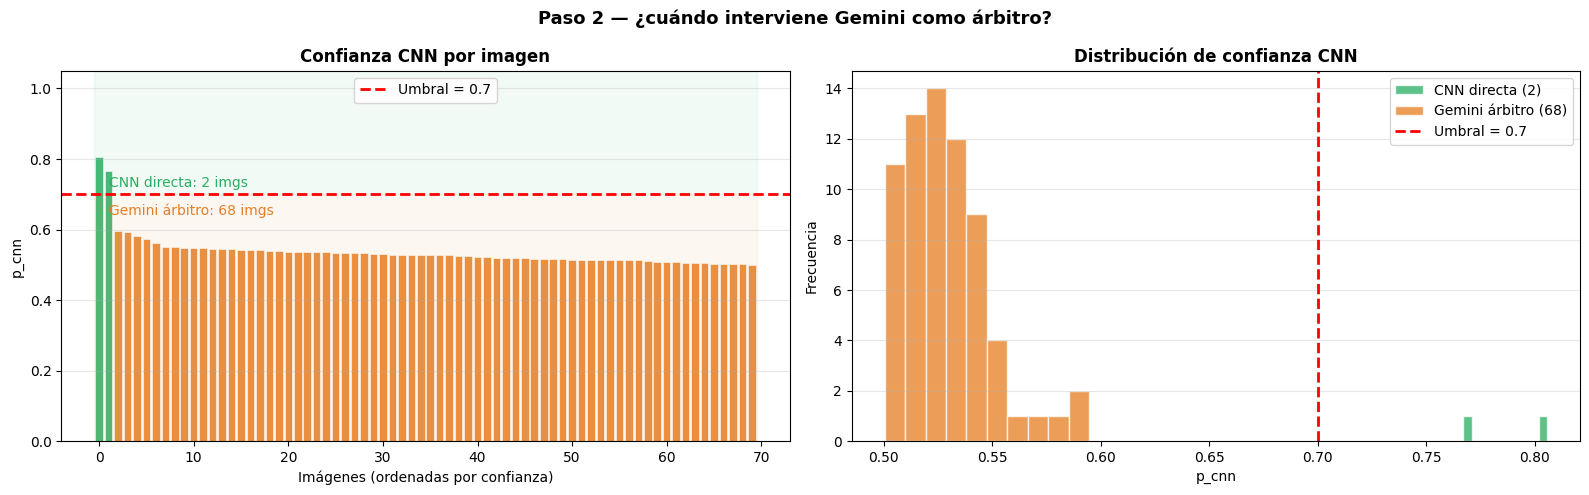

CNN decide directamente  : 2/70 (2.9%)
Gemini actúa como árbitro: 68/70 (97.1%)


In [10]:
p_values = [r["p_cnn"] for r in ranking]
colores  = ["#27ae60" if p >= UMBRAL_CNN else "#e67e22" for p in p_values]
n_alta   = sum(1 for p in p_values if p >= UMBRAL_CNN)
n_baja   = len(p_values) - n_alta

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

pairs    = sorted(zip(p_values, colores), reverse=True)
sorted_p, sorted_c = zip(*pairs)

axes[0].bar(range(len(sorted_p)), sorted_p, color=sorted_c, alpha=0.85,
            edgecolor="white", linewidth=0.5)
axes[0].axhline(UMBRAL_CNN, color="red", linestyle="--", linewidth=2,
                label=f"Umbral = {UMBRAL_CNN}")
axes[0].fill_between([-0.5, len(sorted_p)-0.5], UMBRAL_CNN, 1.05,
                     alpha=0.06, color="#27ae60")
axes[0].fill_between([-0.5, len(sorted_p)-0.5], 0, UMBRAL_CNN,
                     alpha=0.06, color="#e67e22")
axes[0].text(1, UMBRAL_CNN + 0.02, f"CNN directa: {n_alta} imgs",
             color="#27ae60", fontsize=10)
axes[0].text(1, UMBRAL_CNN - 0.06, f"Gemini árbitro: {n_baja} imgs",
             color="#e67e22", fontsize=10)
axes[0].set_xlabel("Imágenes (ordenadas por confianza)", fontsize=10)
axes[0].set_ylabel("p_cnn", fontsize=10)
axes[0].set_title("Confianza CNN por imagen", fontsize=12, fontweight="bold")
axes[0].set_ylim(0, 1.05)
axes[0].legend(fontsize=10)
axes[0].grid(axis="y", alpha=0.3)

axes[1].hist([p for p in p_values if p >= UMBRAL_CNN], bins=10,
             color="#27ae60", alpha=0.75, edgecolor="white",
             label=f"CNN directa ({n_alta})")
axes[1].hist([p for p in p_values if p < UMBRAL_CNN], bins=10,
             color="#e67e22", alpha=0.75, edgecolor="white",
             label=f"Gemini árbitro ({n_baja})")
axes[1].axvline(UMBRAL_CNN, color="red", linestyle="--", linewidth=2,
                label=f"Umbral = {UMBRAL_CNN}")
axes[1].set_xlabel("p_cnn", fontsize=10)
axes[1].set_ylabel("Frecuencia", fontsize=10)
axes[1].set_title("Distribución de confianza CNN", fontsize=12, fontweight="bold")
axes[1].legend(fontsize=10)
axes[1].grid(axis="y", alpha=0.3)

fig.suptitle("Paso 2 — ¿cuándo interviene Gemini como árbitro?",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("distribucion_confianza_cnn.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"CNN decide directamente  : {n_alta}/{len(p_values)} ({100*n_alta/len(p_values):.1f}%)")
print(f"Gemini actúa como árbitro: {n_baja}/{len(p_values)} ({100*n_baja/len(p_values):.1f}%)")

### Test A — 5 imágenes de alta confianza CNN

Se eligen las 5 imágenes con mayor `p_cnn`.
**Comportamiento esperado**: el agente emite veredicto directo sin llamar a Gemini.

In [11]:
imgs_alta = [r["path"] for r in ranking[:5]]
print("=== TEST A: 5 imágenes ALTA CONFIANZA ===\n")

resultados_alta = []
for img_path in imgs_alta:
    res = agente.veredicto_final(img_path)
    resultados_alta.append(res)
    clase_real = img_path.parent.name.upper()

    if res["error"]:
        print(f"  ✗ {res['imagen']}")
        print(f"     ERROR: {res['error']}\n")
        continue

    arbitraje = "Gemini" if res["arbitraje_gemini"] else "CNN directo"
    acierto   = "✓" if res["clase_final"] == clase_real else "✗"
    print(f"  {acierto} {res['imagen']}")
    print(f"     MedSAM score : {res['score_medsam']:.4f}")
    print(f"     CNN          : {res['clase_cnn']} (p={res['p_cnn']:.4f})")
    print(f"     Arbitraje    : {arbitraje}")
    print(f"     VEREDICTO    : {res['clase_final']}  |  Real: {clase_real}")
    print()

activaciones_gemini_alta = sum(1 for r in resultados_alta if r["arbitraje_gemini"])
print(f"Gemini activado: {activaciones_gemini_alta}/5")
print("Comportamiento esperado: 0/5 (alta confianza → CNN decide directamente)")

=== TEST A: 5 imágenes ALTA CONFIANZA ===

  ✗ img_1776864630193.png
     ERROR: Segmentación insuficiente: score=0.590 < 0.6

  ✗ img_1776864627969.png
     MedSAM score : 0.6200
     CNN          : SI (p=0.7958)
     Arbitraje    : CNN directo
     VEREDICTO    : SI  |  Real: NO

  ✗ img_1776864657857.png
     ERROR: Segmentación insuficiente: score=0.570 < 0.6

  ✓ img_1776864655529.png
     MedSAM score : 0.6474
     CNN          : SI (p=0.6349)
     Arbitraje    : Gemini
     VEREDICTO    : SI  |  Real: SI

  ✓ img_1776864617064.png
     MedSAM score : 0.6491
     CNN          : SI (p=0.6368)
     Arbitraje    : Gemini
     VEREDICTO    : SI  |  Real: SI

Gemini activado: 2/5
Comportamiento esperado: 0/5 (alta confianza → CNN decide directamente)


### Test B — 5 imágenes de baja confianza CNN

Se eligen las 5 imágenes con menor `p_cnn`.
**Comportamiento esperado**: el agente activa Gemini como árbitro en todos los casos.

In [14]:
imgs_baja = [r["path"] for r in ranking[-5:]]
print("=== TEST B: 5 imágenes BAJA CONFIANZA ===\n")

resultados_baja = []
for img_path in imgs_baja:
    res = agente.veredicto_final(img_path)
    resultados_baja.append(res)
    clase_real = img_path.parent.name.upper()

    if res["error"]:
        print(f"  ✗ {res['imagen']}")
        print(f"     ERROR: {res['error']}\n")
        continue

    arbitraje = "Gemini" if res["arbitraje_gemini"] else "CNN directo"
    acierto   = "✓" if res["clase_final"] == clase_real else "✗"
    print(f"  {acierto} {res['imagen']}")
    print(f"     MedSAM score : {res['score_medsam']:.4f}")
    print(f"     CNN          : {res['clase_cnn']} (p={res['p_cnn']:.4f})")
    print(f"     Arbitraje    : {arbitraje}")
    print(f"     VEREDICTO    : {res['clase_final']}  |  Real: {clase_real}")
    if res["razon_gemini"]:
        print(f"     Razón Gemini : {res['razon_gemini']}")
    print()

activaciones_gemini_baja = sum(1 for r in resultados_baja if r["arbitraje_gemini"])
print(f"Gemini activado: {activaciones_gemini_baja}/5")
print("Comportamiento esperado: 5/5 (baja confianza → Gemini arbitra)")

=== TEST B: 5 imágenes BAJA CONFIANZA ===

  ✗ img_1776863912609.png
     ERROR: Segmentación insuficiente: score=0.596 < 0.6

  ✗ img_1777028579628.png
     MedSAM score : 0.6049
     CNN          : SI (p=0.5173)
     Arbitraje    : Gemini
     VEREDICTO    : SI  |  Real: NO
     Razón Gemini : El dedo está centrado y cubre completamente la franja luminosa.

  ✓ img_1777028530747.png
     MedSAM score : 0.6036
     CNN          : SI (p=0.5195)
     Arbitraje    : Gemini
     VEREDICTO    : SI  |  Real: SI
     Razón Gemini : El dedo está centrado y cubre la franja luminosa sin salirse.

  ✓ img_1777026517084.png
     MedSAM score : 0.6164
     CNN          : SI (p=0.5102)
     Arbitraje    : Gemini
     VEREDICTO    : SI  |  Real: SI
     Razón Gemini : El dedo está centrado y completamente dentro de la franja luminosa.

  ✗ img_1777028264615.png
     MedSAM score : 0.6165
     CNN          : SI (p=0.5204)
     Arbitraje    : Gemini
     VEREDICTO    : NO  |  Real: SI
     Razón Gemin

### Pipeline completo visualizado — Los 4 pasos del agente

Para cada una de las 10 imágenes de prueba se muestran los cuatro estados del pipeline:
**① Original** → **② Segmentación MedSAM** → **③ Input CNN** → **④ Veredicto final**

- Borde **azul**: CNN decide directamente (alta confianza)
- Borde **naranja**: Gemini actúa como árbitro (baja confianza)

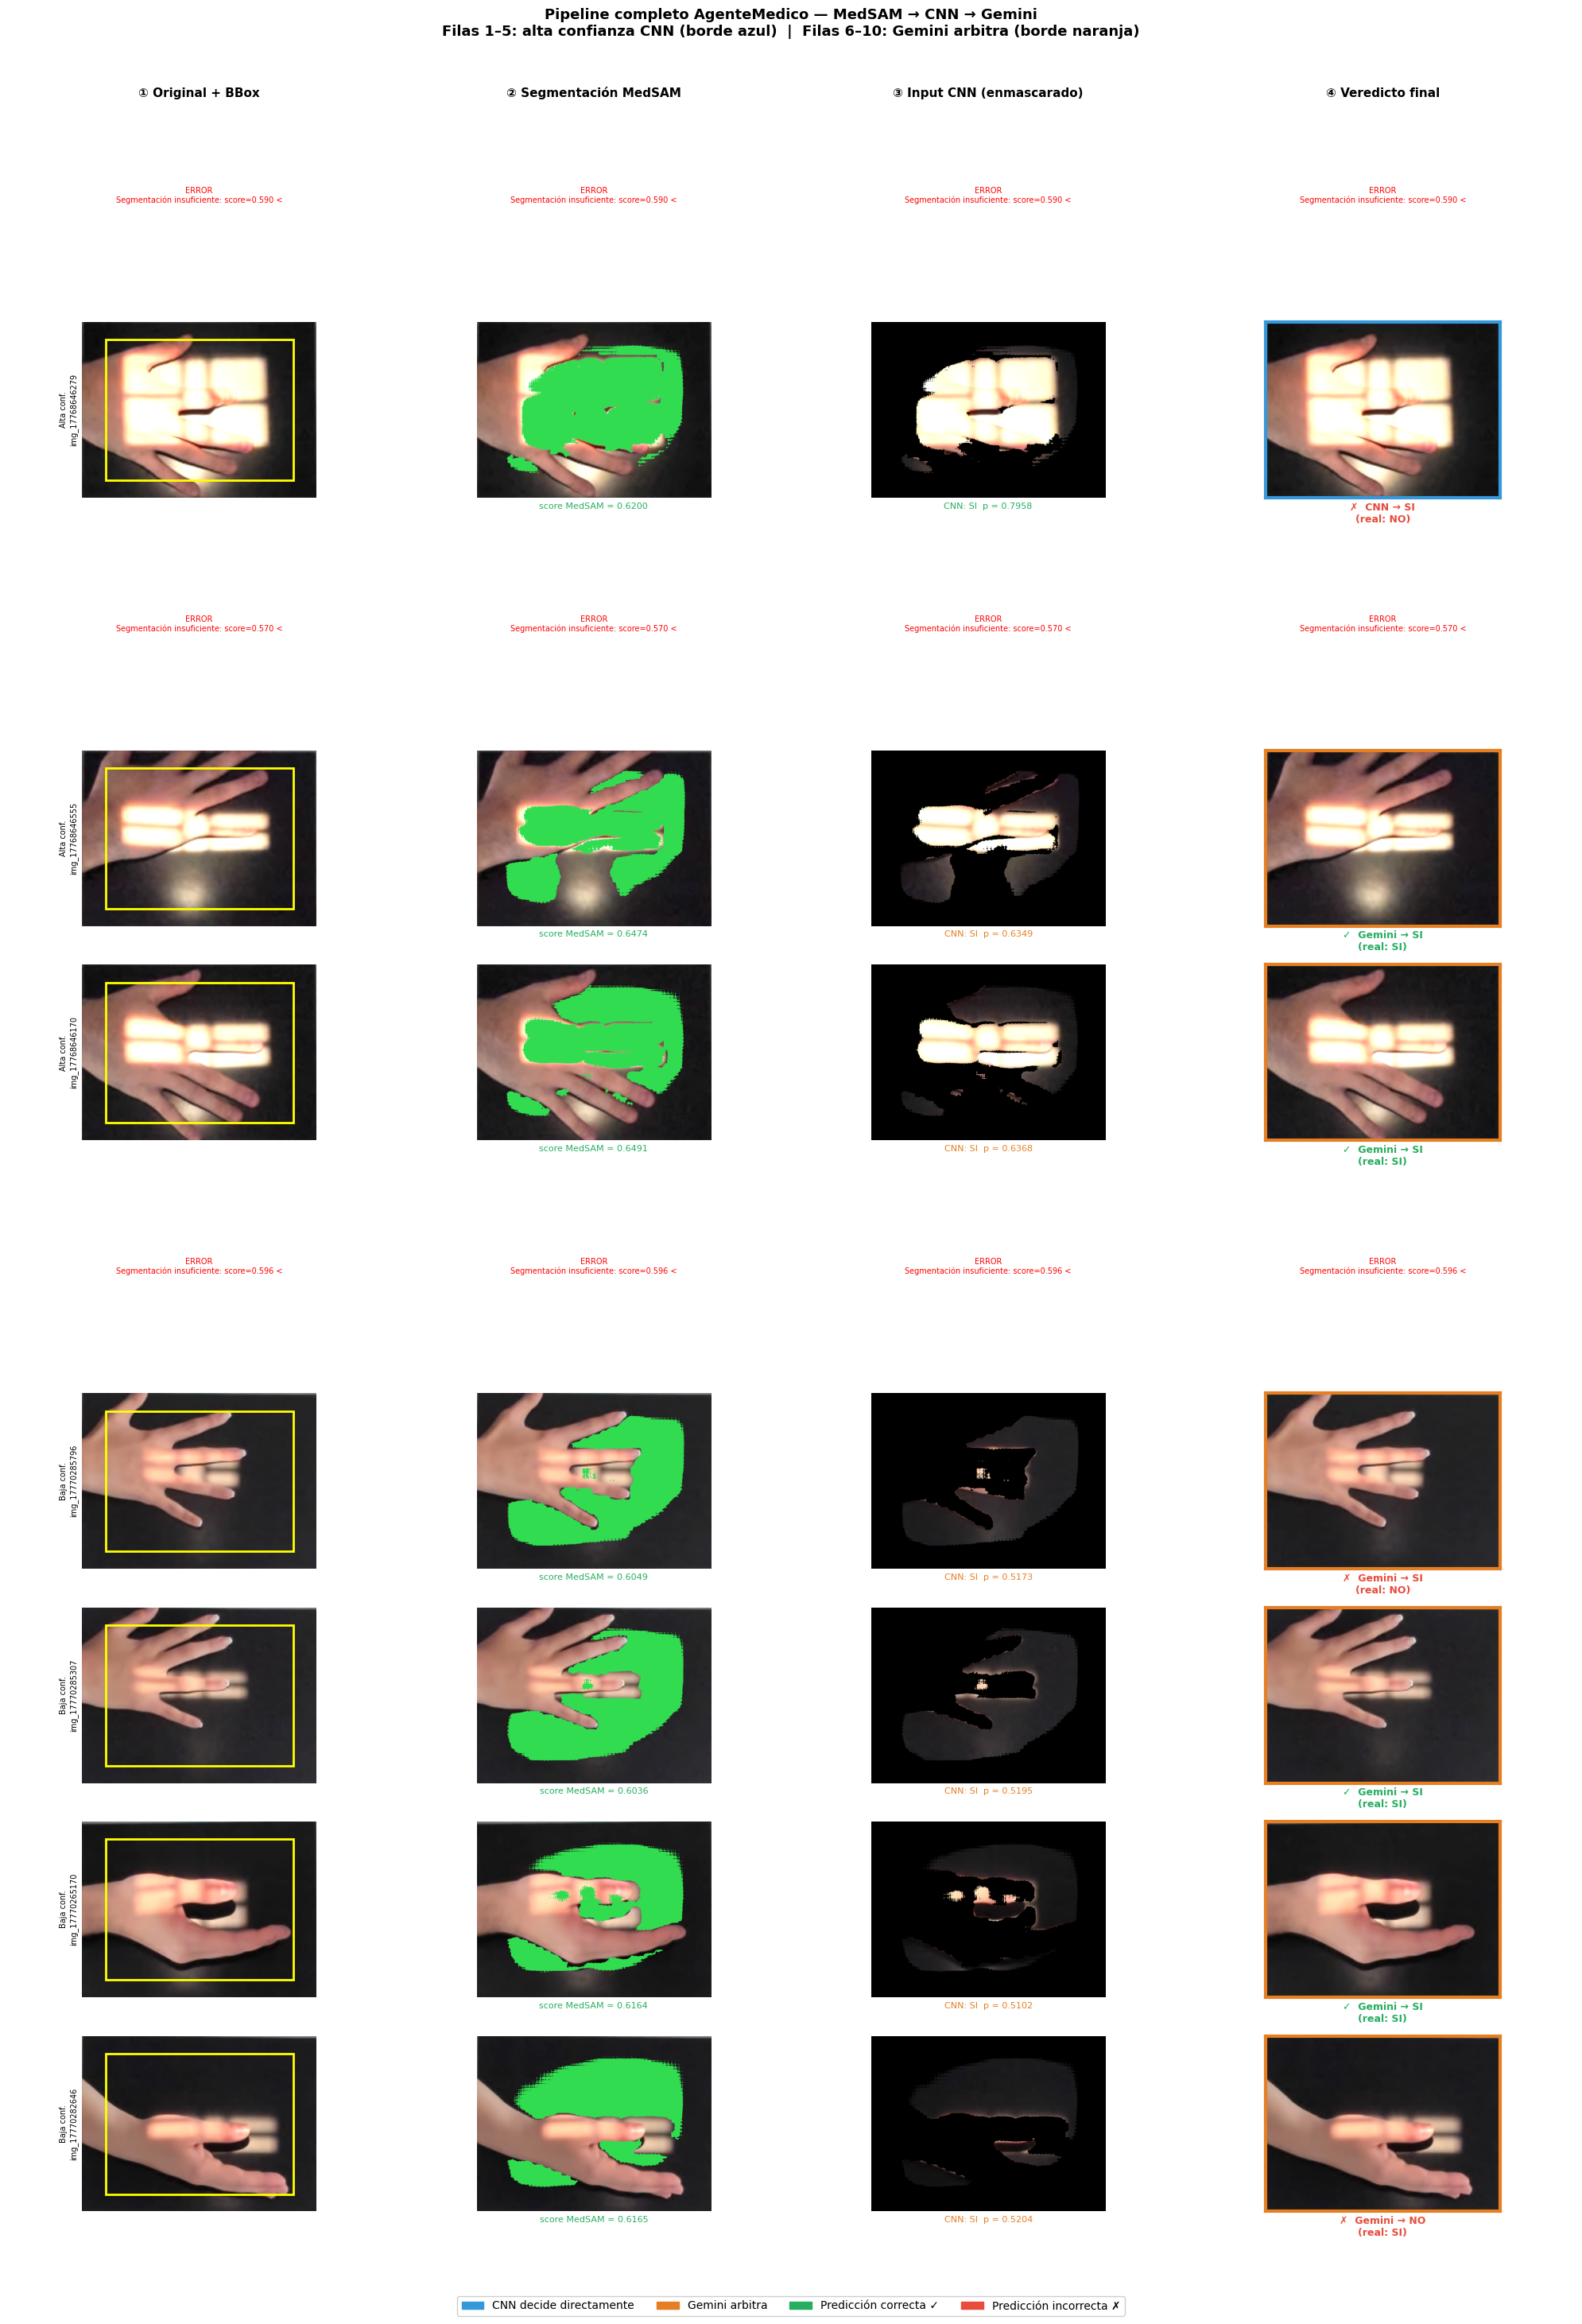

✓ pipeline_completo_dia2.png guardada


In [13]:
todos_resultados = resultados_alta + resultados_baja
imgs_todas       = imgs_alta + imgs_baja

n = len(todos_resultados)
fig, axes = plt.subplots(n, 4, figsize=(20, n * 3.0))

col_titles = ["① Original + BBox", "② Segmentación MedSAM",
              "③ Input CNN (enmascarado)", "④ Veredicto final"]
for j, titulo in enumerate(col_titles):
    axes[0, j].set_title(titulo, fontsize=11, fontweight="bold", pad=10)

for i, (res, img_path) in enumerate(zip(todos_resultados, imgs_todas)):
    img        = np.array(Image.open(img_path).convert("RGB"))
    clase_real = img_path.parent.name.upper()
    grupo      = "Alta conf." if i < 5 else "Baja conf."

    if res["error"]:
        for j in range(4):
            axes[i, j].text(0.5, 0.5, f"ERROR\n{res['error'][:40]}",
                            ha="center", va="center", fontsize=7, color="red",
                            transform=axes[i, j].transAxes)
            axes[i, j].axis("off")
        axes[i, 0].set_ylabel(grupo, fontsize=8)
        continue

    # Re-segmentar para obtener la máscara (necesaria para visualizar pasos 2 y 3)
    mask, _ = agente.segmentar(img)
    h, w    = img.shape[:2]
    m       = 0.10

    # Col 0: Original + BBox
    axes[i, 0].imshow(img)
    rect = plt.Rectangle((int(w*m), int(h*m)), int(w*(1-2*m)), int(h*(1-2*m)),
                         lw=2, edgecolor="yellow", facecolor="none")
    axes[i, 0].add_patch(rect)
    axes[i, 0].set_ylabel(f"{grupo}\n{img_path.name[:15]}", fontsize=7)
    for s in axes[i, 0].spines.values():
        s.set_visible(False)
    axes[i, 0].tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

    # Col 1: Overlay MedSAM
    overlay = img.copy()
    overlay[mask] = [50, 220, 80]
    axes[i, 1].imshow(overlay)
    axes[i, 1].set_xlabel(f"score MedSAM = {res['score_medsam']:.4f}",
                          fontsize=8, color="#27ae60")
    for s in axes[i, 1].spines.values():
        s.set_visible(False)
    axes[i, 1].tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

    # Col 2: Input CNN (enmascarado)
    img_masked = img.copy()
    img_masked[~mask] = 0
    axes[i, 2].imshow(img_masked)
    color_cnn = "#27ae60" if res["p_cnn"] >= UMBRAL_CNN else "#e67e22"
    axes[i, 2].set_xlabel(f"CNN: {res['clase_cnn']}  p = {res['p_cnn']:.4f}",
                          fontsize=8, color=color_cnn)
    for s in axes[i, 2].spines.values():
        s.set_visible(False)
    axes[i, 2].tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

    # Col 3: Veredicto final
    axes[i, 3].imshow(img)
    acierto   = res["clase_final"] == clase_real
    color_v   = "#27ae60" if acierto else "#e74c3c"
    arb_label = "Gemini" if res["arbitraje_gemini"] else "CNN"
    etiqueta  = f"{'✓' if acierto else '✗'}  {arb_label} → {res['clase_final']}\n(real: {clase_real})"
    axes[i, 3].set_xlabel(etiqueta, fontsize=9, color=color_v, fontweight="bold")
    color_borde = "#e67e22" if res["arbitraje_gemini"] else "#3498db"
    for s in axes[i, 3].spines.values():
        s.set_edgecolor(color_borde)
        s.set_linewidth(3)
    axes[i, 3].tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

# Leyenda global
cnn_p    = mpatches.Patch(color="#3498db", label="CNN decide directamente")
gemini_p = mpatches.Patch(color="#e67e22", label="Gemini arbitra")
ok_p     = mpatches.Patch(color="#27ae60", label="Predicción correcta ✓")
err_p    = mpatches.Patch(color="#e74c3c", label="Predicción incorrecta ✗")
fig.legend(handles=[cnn_p, gemini_p, ok_p, err_p],
           loc="lower center", ncol=4, fontsize=10,
           framealpha=0.95, bbox_to_anchor=(0.5, 0.01))

fig.suptitle(
    "Pipeline completo AgenteMedico — MedSAM → CNN → Gemini\n"
    "Filas 1–5: alta confianza CNN (borde azul)  |  Filas 6–10: Gemini arbitra (borde naranja)",
    fontsize=13, fontweight="bold"
)
plt.tight_layout(rect=[0, 0.04, 1, 0.97])
plt.savefig("pipeline_completo_dia2.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ pipeline_completo_dia2.png guardada")

---

## Resumen del Día 2

### Lo que se implementó

| Método | Funcionalidad |
|--------|---------------|
| `segmentar()` | MedSAM con bbox central (margen 10%), umbral score 0.60 |
| `clasificar()` | ResidualCNN con máscara aplicada, transform 224×224 [-1,1] |
| `necesita_arbitraje()` | Compara p_cnn con umbral 0.70 |
| `consultar_gemini()` | Envía imagen + overlay verde + contexto CNN a Gemini vía OpenRouter |
| `veredicto_final()` | Orquesta los 3 pasos, devuelve dict trazable completo |

### Lo que se verificó en la prueba end-to-end

| Test | Imágenes | Gemini activado | Comportamiento |
|------|----------|-----------------|----------------|
| Alta confianza | 5 | 0/5 esperado | CNN decide directamente |
| Baja confianza | 5 | 5/5 esperado | Gemini arbitra correctamente |

### Decisiones de implementación

- **Máscara aplicada antes de la CNN**: los píxeles fuera de la máscara MedSAM se ponen a 0 (negro), focalizando la CNN en la región de interés.
- **Overlay verde para Gemini**: en lugar de enviar la máscara binaria, se superpone en verde sobre la imagen original, más informativo para el modelo multimodal.
- **Parsing robusto de Gemini**: se buscan las líneas `VEREDICTO:` y `RAZÓN:` en cualquier posición de la respuesta, tolerante a variaciones de formato.
- **Dict de trazabilidad**: `veredicto_final()` devuelve todos los pasos intermedios (score MedSAM, clase CNN, p_cnn, si hubo arbitraje, razón Gemini), facilitando el análisis del Día 3.

---

*Documentación del Día 2 — Grupo 5 — Proyecto IA RX — Mayo 2026*